# Anki Flashcard Generator -- LangGraph Development Notebook

This notebook defines the entire agentic workflow for generating Anki flashcards
from PDF documents. Every component -- state schema, prompts, LLM utilities,
node functions, graph assembly -- is built here from scratch so the full
architecture is visible in one place.

**Architecture**: 5-node LangGraph state graph with a conditional quality gate
that routes from `review_quality` back to `generate_flashcards` if structural
validation fails (e.g. too many empty cards). This makes it an agentic
workflow rather than a simple sequential chain.

**Performance design**:
- Chunks sized at 2000 chars, since we are using a 128k context window cloud LLM (mistral-large-3:675b-cloud) to minimize LLM calls
- `chain.batch()` for parallel LLM invocation across all chunks
- Quality baked into the generation prompt (single-pass, no LLM review call)
- Review node does fast rule-based validation (dedup, structural checks)

After validating here, the code is migrated to `.py` modules under `agent/`.

## 1. Setup and Configuration

In [1]:
import csv
import json
import operator
import os
import re
from pathlib import Path
from typing import Annotated, Literal, TypedDict

from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, START, END

load_dotenv(os.path.join("..", ".env"))

OLLAMA_HOST = os.environ.get("OLLAMA_HOST", "http://localhost:11434")
OLLAMA_MODEL = os.environ.get("OLLAMA_MODEL", "mistral-large-3:675b-cloud")

print(f"OLLAMA_HOST:  {OLLAMA_HOST}")
print(f"OLLAMA_MODEL: {OLLAMA_MODEL}")

/home/fjrc/Documents/flashcards-anki-gen/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


OLLAMA_HOST:  http://localhost:11434
OLLAMA_MODEL: mistral-large-3:675b-cloud


## 2. State Schema

The `FlashcardState` TypedDict defines the shared state that flows through
every node in the graph. The `log_messages` field uses an `operator.add`
reducer so each node appends to the log without overwriting previous entries.

In [2]:
class FlashcardState(TypedDict, total=False):
    """Shared state flowing through the flashcard generation graph."""

    # -- Input --
    file_path: str
    output_dir: str

    # -- parse_document outputs --
    documents: list[Document]
    page_count: int

    # -- chunk_text outputs --
    chunks: list[Document]
    chunk_count: int

    # -- generate_flashcards outputs --
    flashcards: list[dict[str, str]]

    # -- review_quality outputs --
    reviewed_flashcards: list[dict[str, str]]
    cards_kept: int
    cards_removed: int
    quality_approved: bool
    retry_count: int

    # -- export_cards outputs --
    csv_path: str
    jsonl_path: str

    # -- Shared (append-only via reducer) --
    log_messages: Annotated[list[str], operator.add]


print("FlashcardState fields:")
for field_name, field_type in FlashcardState.__annotations__.items():
    print(f"  {field_name}: {field_type}")

FlashcardState fields:
  file_path: <class 'str'>
  output_dir: <class 'str'>
  documents: list[langchain_core.documents.base.Document]
  page_count: <class 'int'>
  chunks: list[langchain_core.documents.base.Document]
  chunk_count: <class 'int'>
  flashcards: list[dict[str, str]]
  reviewed_flashcards: list[dict[str, str]]
  cards_kept: <class 'int'>
  cards_removed: <class 'int'>
  quality_approved: <class 'bool'>
  retry_count: <class 'int'>
  csv_path: <class 'str'>
  jsonl_path: <class 'str'>
  log_messages: typing.Annotated[list[str], <built-in function add>]


## 3. LLM Utilities

Shared helpers for building the `ChatOllama` instance and cleaning
JSON output from the LLM (stripping Markdown code fences).

In [3]:
CODE_FENCE_RE = re.compile(r"^```(?:json)?\s*|```$", re.MULTILINE)


def clean_json(raw: str) -> str:
    """Strip triple-backtick fences and surrounding whitespace."""
    return CODE_FENCE_RE.sub("", raw).strip()


def build_llm() -> ChatOllama:
    """Construct a ChatOllama instance from environment variables."""
    return ChatOllama(
        model=OLLAMA_MODEL,
        base_url=OLLAMA_HOST,
        temperature=0.15,
        format="json",
    )


print(f"LLM factory configured: model={OLLAMA_MODEL}, host={OLLAMA_HOST}")

LLM factory configured: model=mistral-large-3:675b-cloud, host=http://localhost:11434


## 4. Prompt Template

A single quality-aware generation prompt that produces high-quality flashcards
in one pass. Quality criteria are embedded directly in the system message,
eliminating the need for a separate LLM review call.

In [4]:
GENERATION_PROMPT = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are an expert educator who creates high-quality Anki flashcards. "
        "Given a text chunk, produce between 3 and 5 question-answer flashcards "
        "that capture the most important concepts.\n\n"
        "Quality criteria (apply these yourself, do NOT produce low-quality cards):\n"
        "- Each question must be specific, unambiguous, and self-contained\n"
        "- Each answer must be concise but complete\n"
        "- Do NOT produce vague, trivially obvious, or duplicate cards\n"
        "- Do NOT produce cards that require the original text to answer\n"
        "- If the chunk contains no meaningful content, return an empty list\n\n"
        "Return ONLY a JSON object with a single key \"flashcards\" containing "
        "a list of objects, each with \"question\" and \"answer\" keys.\n\n"
        "Example output:\n"
        "{{\n"
        '  "flashcards": [\n'
        '    {{"question": "What is X?", "answer": "X is ..."}},\n'
        '    {{"question": "How does Y work?", "answer": "Y works by ..."}}\n'
        "  ]\n"
        "}}",
    ),
    (
        "user",
        "Text chunk:\n"
        '"""\n'
        "{chunk}\n"
        '"""',
    ),
])

print("Prompt defined: GENERATION_PROMPT (quality-aware, single-pass)")

Prompt defined: GENERATION_PROMPT (quality-aware, single-pass)


## 5. Node Functions

Each node is a pure function: `def node(state: FlashcardState) -> dict`
returning only the keys it updates. Nodes are tested individually below.

### 5.1 Parse Document

Loads a PDF file using `PyPDFLoader` and writes the raw `Document` objects
into the graph state.

In [5]:
def parse_document(state: FlashcardState) -> dict:
    """Load a PDF file and return its pages as LangChain Documents."""
    path = Path(state["file_path"]).resolve()
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    loader = PyPDFLoader(str(path))
    documents = loader.load()
    page_count = len(documents)

    return {
        "documents": documents,
        "page_count": page_count,
        "log_messages": [
            f"Loaded {page_count} page(s) from {path.name}."
        ],
    }


# -- Test --
state_after_parse = parse_document({"file_path": "../docs/ru_vocabulary.pdf"})
print(f"Pages loaded: {state_after_parse['page_count']}")
print(f"Log: {state_after_parse['log_messages']}")
print(f"First page preview: {state_after_parse['documents'][0].page_content[:200]}...")

Pages loaded: 11
Log: ['Loaded 11 page(s) from ru_vocabulary.pdf.']
First page preview: BRIEF SPEAKING VOCABULARY  
English Russian Transcription 
Cheers, meetings, introduction  
acquaintance знакомство znakomstva 
arrival приезд priyest 
greeting приветствие privyetstviye 
meeting встр...


### 5.2 Chunk Text

Splits loaded documents into overlapping text chunks using
`RecursiveCharacterTextSplitter`. Chunk size is 2000 chars (not 400)
to minimize the number of LLM calls -- `mistral-large-3` has 128k
context so larger chunks are fine.

In [6]:
CHUNK_SIZE = 2000
CHUNK_OVERLAP = 200


def chunk_text(state: FlashcardState) -> dict:
    """Split documents into overlapping text chunks."""
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=CHUNK_SIZE,
        chunk_overlap=CHUNK_OVERLAP,
    )
    chunks = splitter.split_documents(state["documents"])
    chunk_count = len(chunks)

    return {
        "chunks": chunks,
        "chunk_count": chunk_count,
        "log_messages": [
            f"Split into {chunk_count} chunk(s) "
            f"(size={CHUNK_SIZE}, overlap={CHUNK_OVERLAP})."
        ],
    }


# -- Test --
state_after_chunk = chunk_text({"documents": state_after_parse["documents"]})
print(f"Chunks created: {state_after_chunk['chunk_count']}")
print(f"Log: {state_after_chunk['log_messages']}")
print(f"First chunk preview: {state_after_chunk['chunks'][0].page_content[:200]}...")

Chunks created: 11
Log: ['Split into 11 chunk(s) (size=2000, overlap=200).']
First chunk preview: BRIEF SPEAKING VOCABULARY  
English Russian Transcription 
Cheers, meetings, introduction  
acquaintance знакомство znakomstva 
arrival приезд priyest 
greeting приветствие privyetstviye 
meeting встр...


### 5.3 Generate Flashcards

Uses LCEL `(prompt | llm).batch()` to process all chunks in parallel.
This is the key performance optimization -- instead of 51 sequential LLM
calls, all chunks are dispatched concurrently with a configurable
concurrency limit.

In [7]:
MAX_CONCURRENCY = 2


def generate_flashcards(state: FlashcardState) -> dict:
    """Generate flashcards from all chunks in parallel via chain.batch()."""
    llm = build_llm()
    chain = GENERATION_PROMPT | llm
    chunks = state["chunks"]
    total = len(chunks)

    print(f"  [generate] Dispatching {total} chunk(s) "
          f"(max_concurrency={MAX_CONCURRENCY}) ...", flush=True)

    inputs = [{"chunk": chunk.page_content} for chunk in chunks]
    results = chain.batch(inputs, config={"max_concurrency": MAX_CONCURRENCY})

    flashcards: list[dict[str, str]] = []
    errors = 0

    for i, result in enumerate(results, start=1):
        try:
            parsed = json.loads(clean_json(result.content))
            if isinstance(parsed, list):
                cards = parsed
            elif isinstance(parsed, dict) and "flashcards" in parsed:
                cards = parsed["flashcards"]
            else:
                cards = []
                errors += 1
        except (json.JSONDecodeError, TypeError):
            cards = []
            errors += 1
        flashcards.extend(cards)

    print(f"  [generate] Done: {len(flashcards)} card(s) from {total} chunk(s).",
          flush=True)

    log = f"Generated {len(flashcards)} flashcard(s) from {total} chunk(s)."
    if errors:
        log += f" ({errors} chunk(s) failed to parse.)"

    return {
        "flashcards": flashcards,
        "log_messages": [log],
    }


# -- Test (first 3 chunks) --
state_after_gen = generate_flashcards({"chunks": state_after_chunk["chunks"][:3]})
print(f"Flashcards generated: {len(state_after_gen['flashcards'])}")
print(f"Log: {state_after_gen['log_messages']}")
for card in state_after_gen["flashcards"][:3]:
    print(f"  Q: {card['question']}")
    print(f"  A: {card['answer']}")
    print()

  [generate] Dispatching 3 chunk(s) (max_concurrency=2) ...
  [generate] Done: 16 card(s) from 3 chunk(s).
Flashcards generated: 16
Log: ['Generated 16 flashcard(s) from 3 chunk(s).']
  Q: What is the Russian word for 'acquaintance' and its transcription?
  A: The Russian word is 'знакомство' (transcription: znakomstva).

  Q: How do you say 'I don’t speak Russian' in Russian with transcription?
  A: It is 'Я не говорю по-русски' (transcription: Ya ni-gavaryu pa-ruski).

  Q: What is the Russian phrase for 'How are you?' and its formal equivalent?
  A: The informal phrase is 'Как дела?' (Kak dila?), and the formal equivalent is 'Как Вы поживаете?' (Kak vi pazhivaitye?).



### 5.4 Review Quality

Rule-based validation -- no LLM call. Removes structurally invalid cards
(missing/empty fields) and exact duplicates. Sets `quality_approved=False`
if more than 50% of cards were removed, which triggers the conditional
quality gate to regenerate.

In [8]:
QUALITY_THRESHOLD = 0.5  # reject batch if >50% cards removed


def review_quality(state: FlashcardState) -> dict:
    """Rule-based quality review: remove invalid/duplicate cards, no LLM call."""
    input_cards = state["flashcards"]
    retry_count = state.get("retry_count", 0)

    seen: set[str] = set()
    reviewed: list[dict[str, str]] = []

    for card in input_cards:
        q = card.get("question", "").strip()
        a = card.get("answer", "").strip()
        if not q or not a:
            continue
        key = q.lower()
        if key in seen:
            continue
        seen.add(key)
        reviewed.append({"question": q, "answer": a})

    cards_kept = len(reviewed)
    cards_removed = len(input_cards) - cards_kept
    ratio = cards_kept / max(len(input_cards), 1)
    approved = ratio >= QUALITY_THRESHOLD

    log = (
        f"Review complete (attempt {retry_count + 1}): "
        f"{cards_kept} kept, {cards_removed} removed "
        f"({ratio:.0%} pass rate). Approved: {approved}."
    )
    print(f"  [review] {log}", flush=True)

    return {
        "reviewed_flashcards": reviewed,
        "cards_kept": cards_kept,
        "cards_removed": cards_removed,
        "quality_approved": approved,
        "retry_count": retry_count + 1,
        "log_messages": [log],
    }


# -- Test --
state_after_review = review_quality({"flashcards": state_after_gen["flashcards"]})
print(f"Cards kept: {state_after_review['cards_kept']}")
print(f"Cards removed: {state_after_review['cards_removed']}")
print(f"Approved: {state_after_review['quality_approved']}")
print(f"Log: {state_after_review['log_messages']}")

  [review] Review complete (attempt 1): 16 kept, 0 removed (100% pass rate). Approved: True.
Cards kept: 16
Cards removed: 0
Approved: True
Log: ['Review complete (attempt 1): 16 kept, 0 removed (100% pass rate). Approved: True.']


### 5.5 Export Cards

Writes the reviewed flashcards to both CSV (semicolon-delimited,
UTF-8 with BOM for Excel compatibility) and JSONL formats.

In [9]:
def export_cards(state: FlashcardState) -> dict:
    """Export reviewed flashcards to CSV and JSONL files."""
    output_dir = Path(state.get("output_dir", "./output"))
    output_dir.mkdir(parents=True, exist_ok=True)

    cards = state["reviewed_flashcards"]

    csv_path = output_dir / "flashcards.csv"
    jsonl_path = output_dir / "flashcards.jsonl"

    with csv_path.open("w", encoding="utf-8-sig", newline="") as fh:
        writer = csv.writer(fh, delimiter=";", quoting=csv.QUOTE_MINIMAL)
        for card in cards:
            writer.writerow([card["question"], card["answer"]])

    with jsonl_path.open("w", encoding="utf-8") as fh:
        for card in cards:
            json.dump(card, fh, ensure_ascii=False)
            fh.write("\n")

    return {
        "csv_path": str(csv_path),
        "jsonl_path": str(jsonl_path),
        "log_messages": [
            f"Exported {len(cards)} flashcard(s) to {csv_path} and {jsonl_path}."
        ],
    }


# -- Test --
state_after_export = export_cards({
    "reviewed_flashcards": state_after_review["reviewed_flashcards"],
    "output_dir": "../output",
})
print(f"CSV path:  {state_after_export['csv_path']}")
print(f"JSONL path: {state_after_export['jsonl_path']}")
print(f"Log: {state_after_export['log_messages']}")

CSV path:  ../output/flashcards.csv
JSONL path: ../output/flashcards.jsonl
Log: ['Exported 16 flashcard(s) to ../output/flashcards.csv and ../output/flashcards.jsonl.']


## 6. Graph Assembly

Wire the 5 nodes into a `StateGraph` with a conditional quality gate.
The `quality_gate` function routes back to `generate_flashcards` if
the reviewer rejects the batch and retries remain (max 1).

In [10]:
MAX_RETRIES = 1


def quality_gate(state: FlashcardState) -> Literal["generate_flashcards", "export_cards"]:
    """Route after review: regenerate if rejected and retries remain, else export."""
    if not state.get("quality_approved", True) and state.get("retry_count", 0) <= MAX_RETRIES:
        return "generate_flashcards"
    return "export_cards"


def build_graph():
    """Build and compile the flashcard generation state graph."""
    builder = StateGraph(FlashcardState)

    builder.add_node("parse_document", parse_document)
    builder.add_node("chunk_text", chunk_text)
    builder.add_node("generate_flashcards", generate_flashcards)
    builder.add_node("review_quality", review_quality)
    builder.add_node("export_cards", export_cards)

    builder.add_edge(START, "parse_document")
    builder.add_edge("parse_document", "chunk_text")
    builder.add_edge("chunk_text", "generate_flashcards")
    builder.add_edge("generate_flashcards", "review_quality")
    builder.add_conditional_edges("review_quality", quality_gate)
    builder.add_edge("export_cards", END)

    return builder.compile()


graph = build_graph()
print(f"Graph type: {type(graph).__name__}")
print(f"Nodes: {list(graph.get_graph().nodes.keys())}")

Graph type: CompiledStateGraph
Nodes: ['__start__', 'parse_document', 'chunk_text', 'generate_flashcards', 'review_quality', 'export_cards', '__end__']


## 7. End-to-End Test

Invoke the full compiled graph on `docs/ru_vocabulary.pdf`. This runs all
5 nodes in sequence (with the conditional quality gate) as a single
`graph.invoke()` call.

In [11]:
import time

start = time.time()
for event in graph.stream(
    {"file_path": "../docs/ru_vocabulary.pdf", "output_dir": "../output"},
    stream_mode="updates",
):
    for node_name, node_output in event.items():
        elapsed = time.time() - start
        msgs = node_output.get("log_messages", [])
        for msg in msgs:
            print(f"  [{elapsed:5.1f}s] [{node_name}] {msg}")

elapsed = time.time() - start
print(f"\nDone in {elapsed:.1f}s.")

  [  0.5s] [parse_document] Loaded 11 page(s) from ru_vocabulary.pdf.
  [  0.5s] [chunk_text] Split into 11 chunk(s) (size=2000, overlap=200).
  [generate] Dispatching 11 chunk(s) (max_concurrency=2) ...
  [generate] Done: 55 card(s) from 11 chunk(s).
  [ 29.9s] [generate_flashcards] Generated 55 flashcard(s) from 11 chunk(s).
  [review] Review complete (attempt 1): 55 kept, 0 removed (100% pass rate). Approved: True.
  [ 29.9s] [review_quality] Review complete (attempt 1): 55 kept, 0 removed (100% pass rate). Approved: True.
  [ 29.9s] [export_cards] Exported 55 flashcard(s) to ../output/flashcards.csv and ../output/flashcards.jsonl.

Done in 29.9s.


## 8. Graph Visualization

Render the compiled graph as a Mermaid diagram and save it as a PNG
to the project root. The PNG is generated via `draw_mermaid_png()`
which uses the Mermaid.ink API.

Graph saved to /home/fjrc/Documents/flashcards-anki-gen/graph.png


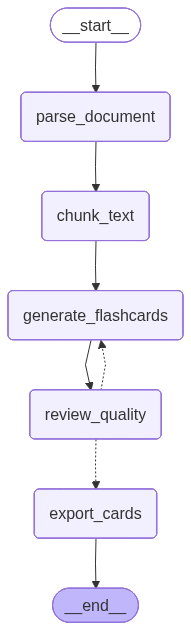

In [12]:
from IPython.display import display, Image, Markdown

# Save PNG to project root
png_data = graph.get_graph().draw_mermaid_png()
png_path = Path("..") / "graph.png"
png_path.write_bytes(png_data)
print(f"Graph saved to {png_path.resolve()}")

# Display the PNG inline
display(Image(data=png_data))